In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import selfies as sf
import numpy as np
from torch.utils.data import DataLoader, Dataset
import os

print(os.path.abspath(os.getcwd()))

/home/jovyan/Research Project/sdf_data


In [2]:
# Define device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # Prints 'cuda' if GPU is available, else 'cpu'

Using device: cpu


In [3]:
# Load the enriched dataset (assumed to be in the same folder)
file_path = "/home/jovyan/Research Project/sdf_data/data.pkl"
df = pd.read_pickle(file_path)

In [4]:
# Ensure column name consistency
if "SMILES" in df.columns:
    smiles_column = "SMILES"
elif "smiles" in df.columns:
    smiles_column = "smiles"
else:
    raise ValueError("Dataset must contain a column named 'SMILES' or 'smiles'.")

In [5]:
# Convert SMILES to SELFIES
def smiles_to_selfies(smiles):
    try:
        return sf.encoder(smiles)
    except:
        return None  # Return None for invalid molecules

df["SELFIES"] = df[smiles_column].apply(smiles_to_selfies)
df = df.dropna(subset=["SELFIES"])  # Drop invalid conversions

In [6]:
# Extract unique SELFIES symbols to create vocabulary
all_selfies = "".join(df["SELFIES"].tolist())  # Concatenate all SELFIES
selfies_alphabet = list(set(sf.split_selfies(all_selfies)))  # Unique tokens
selfies_alphabet.sort()  # Ensure consistent ordering

In [7]:
# Add special tokens
selfies_alphabet = ["<PAD>", "<START>", "<END>"] + selfies_alphabet
token_to_idx = {token: idx for idx, token in enumerate(selfies_alphabet)}
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

max_seq_length = max(len(list(sf.split_selfies(s))) for s in df["SELFIES"]) + 2

In [8]:
# Convert SELFIES to token indices
def selfies_to_indices(selfies, max_length):
    tokens = ["<START>"] + list(sf.split_selfies(selfies)) + ["<END>"]  # Convert generator to list
    indices = [token_to_idx[token] for token in tokens]
    indices += [token_to_idx["<PAD>"]] * (max_length - len(indices))  # Padding
    return indices[:max_length]  # Ensure fixed length

df["SELFIES_TOKENS"] = df["SELFIES"].apply(lambda x: selfies_to_indices(x, max_seq_length))

In [9]:
# Define MolecularDataset class
class MolecularDataset(Dataset):
    def __init__(self, selfies_token_list):
        self.selfies_tokens = selfies_token_list
    
    def __len__(self):
        return len(self.selfies_tokens)
    
    def __getitem__(self, idx):
        return torch.tensor(self.selfies_tokens[idx], dtype=torch.long)

In [10]:
# Extract SELFIES token lists
dataset = MolecularDataset(df["SELFIES_TOKENS"].tolist())

In [11]:
# Create DataLoader
batch_size=64
data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"✅ Dataset successfully loaded with {len(dataset)} molecules using raw SELFIES for training.")

✅ Dataset successfully loaded with 716 molecules using raw SELFIES for training.


In [12]:
# --------------------
# 2️⃣ WGAN-GP Architecture (Updated for Sequence Processing)
# --------------------
class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, vocab_size, max_seq_length):
        super(Generator, self).__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.max_seq_length = max_seq_length

    def forward(self, z):
        batch_size = z.size(0)
        h0 = torch.zeros(1, batch_size, hidden_dim).to(z.device)
        c0 = torch.zeros(1, batch_size, hidden_dim).to(z.device)

        inputs = torch.full((batch_size, self.max_seq_length), token_to_idx["<START>"]).to(z.device)
        inputs = self.embedding(inputs)

        lstm_out, _ = self.lstm(inputs, (h0, c0))
        outputs = self.fc(lstm_out)  # Predict token logits
        return outputs

class Discriminator(nn.Module):
    def __init__(self, vocab_size, max_seq_length, hidden_dim):
        super(Discriminator, self).__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_dim)  # For token indices
        self.conv = nn.Conv1d(hidden_dim, 256, kernel_size=3, padding=1)
        self.fc = nn.Linear(256 * max_seq_length, 1)

    def forward(self, x):
        if x.dtype == torch.long:  # If input is token indices, apply embedding
            x = self.embedding(x).permute(0, 2, 1)  # (batch, hidden_dim, seq_length)
        else:  # If input is already an embedding (from GP), skip embedding
            x = x.permute(0, 2, 1)  

        x = torch.relu(self.conv(x))
        x = x.view(x.size(0), -1)  # Flatten
        return self.fc(x)

In [13]:
# Initialize models
latent_dim = 128
hidden_dim = 512
vocab_size = len(selfies_alphabet)
generator = Generator(latent_dim, hidden_dim, vocab_size, max_seq_length)
discriminator = Discriminator(vocab_size, max_seq_length, hidden_dim)

def compute_gradient_penalty(D, real_samples, fake_samples, embedding_layer):
    batch_size = real_samples.shape[0]  # Get actual batch size (this changes in last batch)
    
    # Ensure alpha matches the actual batch size dynamically
    alpha = torch.rand((batch_size, 1, 1), device=real_samples.device)  # Matches batch size ✅

    # Convert token indices to embeddings before interpolation
    real_embed = embedding_layer(real_samples.long())  # Shape: (batch_size, seq_length, embedding_dim)
    fake_embed = embedding_layer(fake_samples.long())  # Shape: (batch_size, seq_length, embedding_dim)

    # Ensure alpha correctly broadcasts across dimensions
    interpolates = (alpha * real_embed) + ((1 - alpha) * fake_embed)  # Now properly sized ✅
    interpolates.requires_grad_(True)  # Track gradients ✅

    d_interpolates = D(interpolates)  # Discriminator forward pass

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True
    )[0]

    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

Epoch 0, Loss D: -141.9412841796875, Loss G: 110.62126922607422


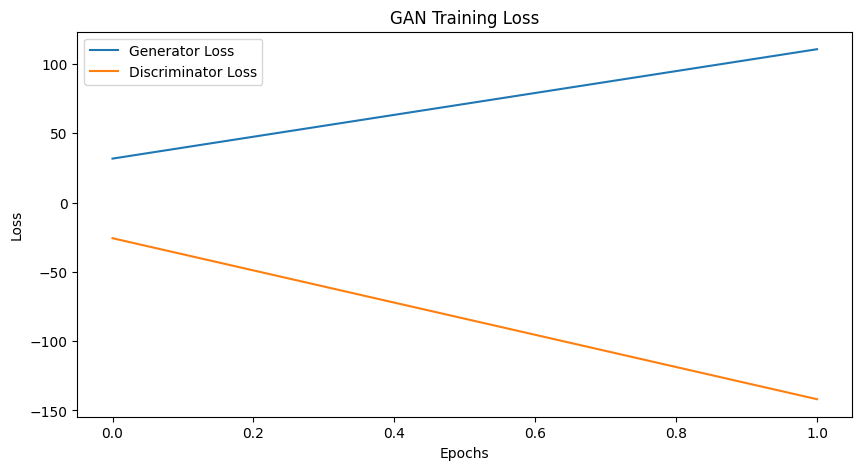

Epoch 25, Loss D: -109845.875, Loss G: 56013.12109375


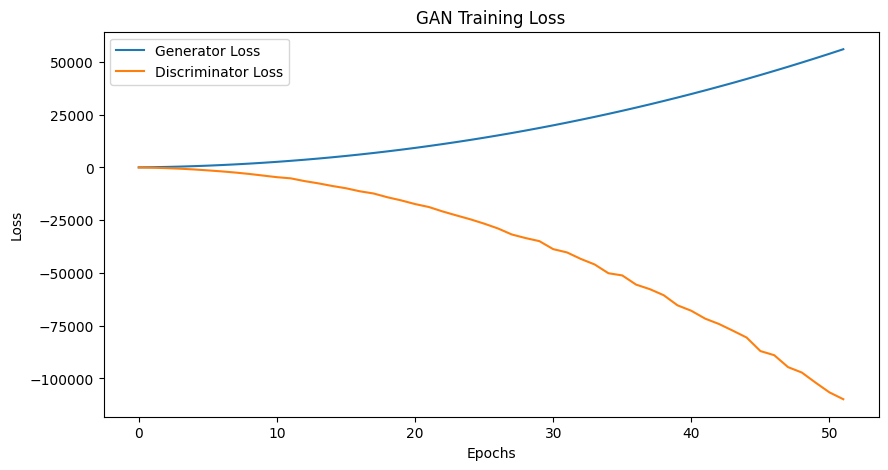

Epoch 50, Loss D: -431874.21875, Loss G: 219542.09375


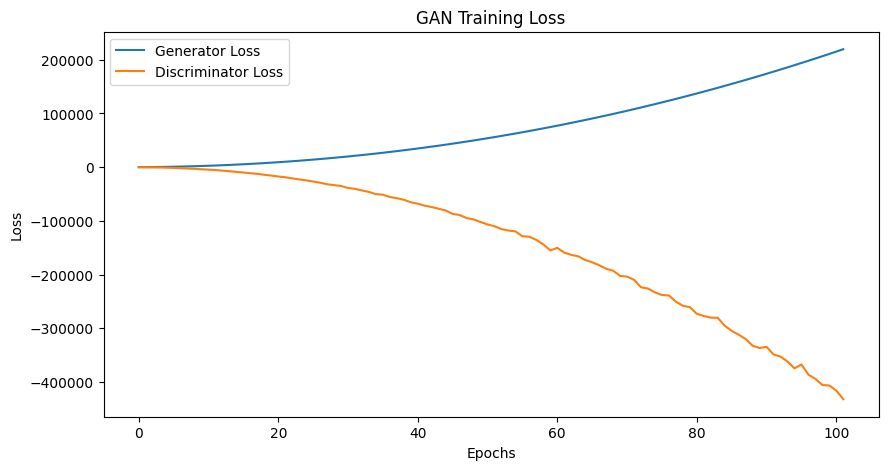

KeyboardInterrupt: 

In [14]:
# --------------------
# 3️⃣ Training Loop (WGAN-GP)
# --------------------
optimizer_G = optim.Adam(generator.parameters(), lr=0.00005, betas=(0.5, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.9))

n_epochs = 5000
lambda_gp = 10
losses_G, losses_D = [], []

import matplotlib.pyplot as plt
def plot_losses():
    plt.figure(figsize=(10, 5))
    plt.plot(losses_G, label='Generator Loss')
    plt.plot(losses_D, label='Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('GAN Training Loss')
    plt.show()

n_critic = 5  # number of D updates per G update
real_data_iter = iter(data_loader)

for epoch in range(n_epochs):
    # For each generator update, update discriminator n_critic times.
    for _ in range(len(data_loader) // n_critic):
        # Update Discriminator n_critic times
        for d_iter in range(n_critic):
            try:
                real_samples = next(real_data_iter)
            except StopIteration:
                real_data_iter = iter(data_loader)
                real_samples = next(real_data_iter)
            batch_size = real_samples.shape[0]
            real_samples = real_samples.long().to(device)
    
            optimizer_D.zero_grad()
            z = torch.randn(batch_size, latent_dim).to(device)
            fake_samples = generator(z).argmax(dim=-1).detach().long().to(device)
    
            loss_D_real = -torch.mean(discriminator(real_samples))
            loss_D_fake = torch.mean(discriminator(fake_samples))
            gradient_penalty = compute_gradient_penalty(
                discriminator, real_samples, fake_samples, discriminator.embedding
            )
    
            loss_D = loss_D_real + loss_D_fake + lambda_gp * gradient_penalty
            loss_D.backward()
    
            # Apply Gradient Clipping to Discriminator
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            optimizer_D.step()
    
        # After n_critic discriminator updates, update the generator once
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_samples = generator(z).argmax(dim=-1).long().to(device)
        loss_G = -torch.mean(discriminator(fake_samples))
        loss_G.backward()
    
        # Apply Gradient Clipping to Generator
        torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
        optimizer_G.step()
    
        losses_G.append(loss_G.item())
        losses_D.append(loss_D.item())
    
    if epoch % 25 == 0:
        print(f"Epoch {epoch}, Loss D: {loss_D.item()}, Loss G: {loss_G.item()}")
        plot_losses()

In [ ]:
# Given generated embeddings from Generator
generated_embeds = generator(z)  # Output shape: (batch_size, max_seq_length, embedding_dim)

# Convert embeddings to token indices using argmax (assuming softmax is applied)
generated_indices = generated_embeds.argmax(dim=-1)  # Shape: (batch_size, max_seq_length)

In [ ]:
def indices_to_selfies(indices):
    """
    Convert a sequence of token indices back to a SELFIES string.
    """
    selfies_tokens = [idx_to_token[idx] for idx in indices if idx_to_token[idx] not in ["<PAD>", "<START>", "<END>"]]
    return "".join(selfies_tokens)

# Convert each generated sequence
generated_selfies = [indices_to_selfies(seq.tolist()) for seq in generated_indices]

In [ ]:
import selfies as sf

def selfies_to_smiles(selfies):
    """
    Convert a SELFIES string to a SMILES string.
    """
    return sf.decoder(selfies)

generated_smiles = [selfies_to_smiles(s) for s in generated_selfies]